# Exercise 02 : Bar




In [1]:
import pandas as pd
import sqlite3

data = sqlite3.connect('../data/checking-logs.sqlite')

df = pd.read_sql_query("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", data)

data.close()

## Подготовка таблицы к построению графика
#### Приведение форматов данных




In [2]:
df['datetime'] = pd.to_datetime(df['timestamp']).dt.date
df['timestamp'] = pd.to_datetime(df['timestamp'])
df

,timestamp,datetime
0,2020-04-17 05:19:02.744528,2020-04-17
1,2020-04-17 05:22:35.249331,2020-04-17
2,2020-04-17 05:22:45.549397,2020-04-17
3,2020-04-17 05:34:14.691200,2020-04-17
4,2020-04-17 05:34:24.422370,2020-04-17
...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21
3203,2020-05-21 20:22:41.785725,2020-05-21
3204,2020-05-21 20:22:41.877806,2020-05-21
3205,2020-05-21 20:37:00.129678,2020-05-21


#### Определение времени суток




In [3]:
df["daytime"] = pd.cut(
    df["timestamp"].dt.hour,
    bins=[0, 4, 10, 17, 24],
    labels=["night", "morning", "afternoon", "evening"],
    right=False
)

df

,timestamp,datetime,daytime
0,2020-04-17 05:19:02.744528,2020-04-17,morning
1,2020-04-17 05:22:35.249331,2020-04-17,morning
2,2020-04-17 05:22:45.549397,2020-04-17,morning
3,2020-04-17 05:34:14.691200,2020-04-17,morning
4,2020-04-17 05:34:24.422370,2020-04-17,morning
...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,evening
3203,2020-05-21 20:22:41.785725,2020-05-21,evening
3204,2020-05-21 20:22:41.877806,2020-05-21,evening
3205,2020-05-21 20:37:00.129678,2020-05-21,evening


## Построение графика




<Axes: title={'center': 'Commits per day'}, xlabel='Date', ylabel='Number of Commits'>

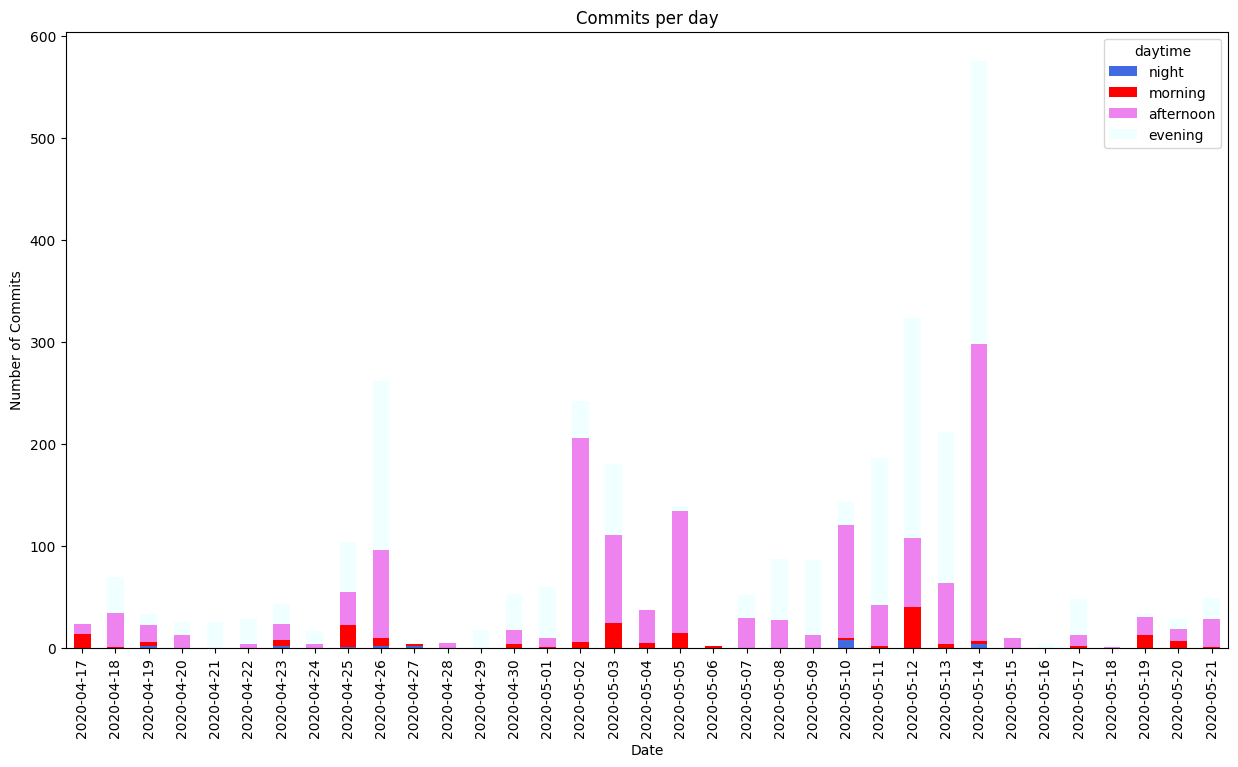

In [4]:
grouped = df.groupby(['datetime', 'daytime'], observed=False).size().unstack(fill_value=0)  
colors = ['royalblue', 'red', 'violet', 'azure']
ax = grouped.plot(kind='bar', stacked=True, figsize=(15, 8), color=colors, title="Commits per day") 

ax.set_xlabel("Date")  
ax.set_ylabel("Number of Commits")  
ax.legend(title="daytime")  
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

display(ax)

## When do our users usually commit the labs: in the night, morning, afternoon, or evening?
#### evening and afternoon


#### 2020-05-12




In [5]:
daytime_counts = df["daytime"].value_counts()
daytime_counts

daytime
evening      1611
afternoon    1391
morning       184
night          21
Name: count, dtype: int64

In [6]:
evening_commits = df[df['daytime'] == 'evening'].groupby('datetime').size()
afternoon_commits = df[df['daytime'] == 'afternoon'].groupby('datetime').size()
comparison_df = pd.DataFrame({"evening": evening_commits, "afternoon": afternoon_commits}).fillna(0)
valid_days = comparison_df[comparison_df["evening"] > comparison_df["afternoon"]]
final_day = valid_days["evening"].idxmax()
final_day

datetime.date(2020, 5, 12)